<a href="https://qworld.net" target="_blank" align="left"><img src="../../qworld/images/header.jpg"  align="left"></a>
$ \newcommand{\bra}[1]{\langle #1|} $
$ \newcommand{\ket}[1]{|#1\rangle} $
$ \newcommand{\braket}[2]{\langle #1|#2\rangle} $
$ \newcommand{\dot}[2]{ #1 \cdot #2} $
$ \newcommand{\biginner}[2]{\left\langle #1,#2\right\rangle} $
$ \newcommand{\mymatrix}[2]{\left( \begin{array}{#1} #2\end{array} \right)} $
$ \newcommand{\myvector}[1]{\mymatrix{c}{#1}} $
$ \newcommand{\myrvector}[1]{\mymatrix{r}{#1}} $
$ \newcommand{\mypar}[1]{\left( #1 \right)} $
$ \newcommand{\mybigpar}[1]{ \Big( #1 \Big)} $
$ \newcommand{\sqrttwo}{\frac{1}{\sqrt{2}}} $
$ \newcommand{\dsqrttwo}{\dfrac{1}{\sqrt{2}}} $
$ \newcommand{\onehalf}{\frac{1}{2}} $
$ \newcommand{\donehalf}{\dfrac{1}{2}} $
$ \newcommand{\hadamard}{ \mymatrix{rr}{ \sqrttwo & \sqrttwo \\ \sqrttwo & -\sqrttwo }} $
$ \newcommand{\vzero}{\myvector{1\\0}} $
$ \newcommand{\vone}{\myvector{0\\1}} $
$ \newcommand{\stateplus}{\myvector{ \sqrttwo \\  \sqrttwo } } $
$ \newcommand{\stateminus}{ \myrvector{ \sqrttwo \\ -\sqrttwo } } $
$ \newcommand{\myarray}[2]{ \begin{array}{#1}#2\end{array}} $
$ \newcommand{\X}{ \mymatrix{cc}{0 & 1 \\ 1 & 0}  } $
$ \newcommand{\I}{ \mymatrix{rr}{1 & 0 \\ 0 & 1}  } $
$ \newcommand{\Z}{ \mymatrix{rr}{1 & 0 \\ 0 & -1}  } $
$ \newcommand{\Htwo}{ \mymatrix{rrrr}{ \frac{1}{2} & \frac{1}{2} & \frac{1}{2} & \frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & \frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} \\ \frac{1}{2} & -\frac{1}{2} & -\frac{1}{2} & \frac{1}{2} } } $
$ \newcommand{\CNOT}{ \mymatrix{cccc}{1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \\ 0 & 0 & 0 & 1 \\ 0 & 0 & 1 & 0} } $
$ \newcommand{\norm}[1]{ \left\lVert #1 \right\rVert } $
$ \newcommand{\pstate}[1]{ \lceil \mspace{-1mu} #1 \mspace{-1.5mu} \rfloor } $
$ \newcommand{\greenbit}[1] {\mathbf{{\color{green}#1}}} $
$ \newcommand{\bluebit}[1] {\mathbf{{\color{blue}#1}}} $
$ \newcommand{\redbit}[1] {\mathbf{{\color{red}#1}}} $
$ \newcommand{\brownbit}[1] {\mathbf{{\color{brown}#1}}} $
$ \newcommand{\blackbit}[1] {\mathbf{{\color{black}#1}}} $

# Solutions - What Is ML and What Is QML?

_Prepared by Claudia Zendejas-Morales_

This notebook contains complete solutions for the embedded tasks in notebook `1.1`.

<a id="task1-solution"></a>

## Task 1 (coding): One complete solution

This solution follows the same pipeline as the baseline example, but on nonlinear data and with two models for comparison.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

In [2]:
X, y = make_moons(n_samples=400, noise=0.25, random_state=11)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=11, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=11)
svm_rbf = SVC(kernel="rbf", gamma="scale", random_state=11)

log_reg.fit(X_train_scaled, y_train)
svm_rbf.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_pred_svm = svm_rbf.predict(X_test_scaled)

acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("Logistic Regression")
print(f"  Accuracy: {acc_lr:.3f}")
print(f"  F1 score: {f1_lr:.3f}")
print("RBF SVM")
print(f"  Accuracy: {acc_svm:.3f}")
print(f"  F1 score: {f1_svm:.3f}")

Logistic Regression
  Accuracy: 0.890
  F1 score: 0.897
RBF SVM
  Accuracy: 0.900
  F1 score: 0.904


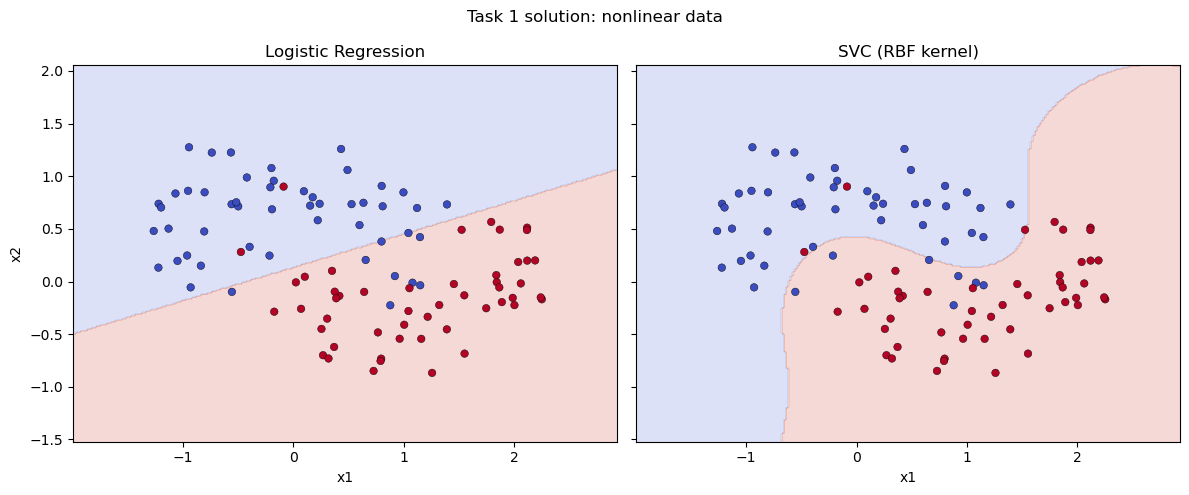

In [3]:
x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

zz_lr = log_reg.predict(grid_scaled).reshape(xx.shape)
zz_svm = svm_rbf.predict(grid_scaled).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

axes[0].contourf(xx, yy, zz_lr, alpha=0.20, cmap="coolwarm")
axes[0].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", s=30, edgecolor="k", linewidth=0.3)
axes[0].set_title("Logistic Regression")
axes[0].set_xlabel("x1")
axes[0].set_ylabel("x2")

axes[1].contourf(xx, yy, zz_svm, alpha=0.20, cmap="coolwarm")
axes[1].scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="coolwarm", s=30, edgecolor="k", linewidth=0.3)
axes[1].set_title("SVC (RBF kernel)")
axes[1].set_xlabel("x1")

plt.suptitle("Task 1 solution: nonlinear data")
plt.tight_layout()
plt.show()

#### Task 1 conclusion: which model is more suitable?

For this nonlinear `make_moons` dataset, `SVC(kernel="rbf")` is usually more suitable than `LogisticRegression` because it can learn curved decision boundaries. Logistic Regression is linear in the original feature space, so it tends to underfit this shape unless extra feature engineering is added. The Accuracy/F1 comparison should reflect that difference.

<a id="task2-solution"></a>

## Task 2 (reflection): Example answer

Toy problem: binary classification on 2D synthetic data.

1. Reasonable baseline for this classical-data toy problem: Logistic Regression with standardized features.
2. Metric and validation protocol: report F1 and accuracy on a held-out test set after model selection on validation data.
3. One concrete reason QML might help: a nonlinear quantum feature map could provide a richer representation than a purely linear baseline on curved decision boundaries.
4. Two unfair-comparison risks and mitigations:
   - Risk: leakage in preprocessing. Mitigation: fit scaler only on train split.
   - Risk: asymmetric tuning effort (heavy tuning on quantum, none on classical). Mitigation: use comparable hyperparameter-search budgets.